# T1 Measurement - without using Qiskit pulse 
### For class 2026 spring "Introduction to quantum information and quantum computing" Seoul National University, Department of Physics and Astronomy Instructor: Dohun Kim 

#### Has been updated for Qiskit 2.3.0 as of 2026.03.02

## Inversion recovery measurement

In this example, we provide a simple structure that student can use to build a program for T1 measuremet.

### Step 1: Create quantum circuit

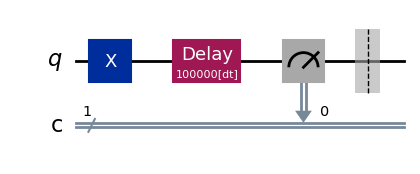

In [8]:
# loading necessary packages
from qiskit.circuit import QuantumRegister, ClassicalRegister, QuantumCircuit, Parameter 

# Define registers
qr = QuantumRegister(1, 'q')
cr = ClassicalRegister(1, 'c')
qc = QuantumCircuit(qr, cr)

# Initialize the qubit in 1 states by X gate.
qc.x(0)

# Put delat before a measurement

qc.delay(100000, unit='dt')
qc.measure(0,0)
qc.barrier()

qc.draw("mpl")

### Step 2: Optimize problem for quantum execution

As seen in the previous example, to run our experiment on a real quantum computer, we need to load Qiskit Runtime Service, and select a quantum computer (or a "backend"). Below, we simply select the least busy quantum computer available to us.

In [9]:
# Load the Qiskit Runtime service
from qiskit_ibm_runtime import QiskitRuntimeService #Import necessary packages
service = QiskitRuntimeService() 

# Load the Runtime primitive
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Use the least busy backend
backend = service.least_busy(operational=True, simulator=False, min_num_qubits = 1)
print(backend.name)

ibm_kingston


In [10]:
backend.dt

4e-09

We now must transpile the circuit, meaning we must map our circuit onto the base gates available to our chosen quantum computer, and we want to optimize our circuit for running on that quantum computer.

In [11]:
# Transpile the circuit and optimize for running on the quantum computer selected
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
qc_ibm = pm.run(qc)

### Step 3: Execute using Qiskit Runtime Primitives

Now we want to run this on a real quantum computer. All the necessary syntax for that is in the code block below.

In [12]:
# Specify the number of shots for repeated measurements.
num_shots = 1024

# Open plan users should use job mode, not Session mode.
# In job mode, pass the backend directly to the primitive.
sampler = Sampler(mode=backend)
job = sampler.run([qc_ibm], shots=num_shots)
print(f"Submitted job: {job.job_id()}")

dist = job.result()
counts = dist[0].data.c.get_counts()


Submitted job: d84qfiftjchs73bqieb0


### Step 4: Post-processing and classical analysis

For this very simple experiment, classical analysis just consists of visualizing the experimental outcome.

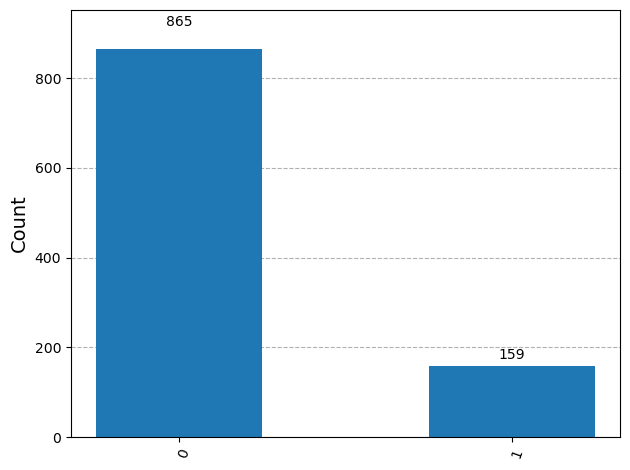

In [13]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

#### Homework:
<details>
<summary>
Above example is fine to see state relaxation by running the circuit with various delay times. Modify the code to prepare a batch of quantum circuits with various delay times, run them in Qiskit batch mode, and plot the final result (Prob. of state 1 vs. delay time (in actual time unit)). Also fit the result with exponential decay function to obtain T1 time of a typical qubit in IBM quantum computer. 


### Homework A: delay sweep를 이용한 T1 측정

이 절에서는 inversion-recovery 방식으로 T1을 측정한다. 먼저 qubit을 $|1\rangle$ 상태로 준비한 뒤, 여러 delay time 동안 기다리고 마지막에 $|1\rangle$로 측정될 확률을 구한다. delay time은 읽기 쉽도록 초 단위로 먼저 정하고, 실제 회로를 만들 때는 backend의 기본 시간 단위인 `dt`로 변환한다.

측정한 $P(1)$은

$$
P(1)=A e^{-t/T_1}+B
$$

형태의 지수감쇠 함수로 fitting하여 T1 값을 얻는다.

In [39]:
# Common packages for Homework A
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def choose_qubit_by_t1(backend):
    """Choose one physical qubit and use it consistently for T1, Ramsey, and echo."""
    qprops = backend.target.qubit_properties
    t1_values = []
    for i, prop in enumerate(qprops):
        if prop is not None and getattr(prop, 't1', None) is not None:
            t1_values.append((i, prop.t1))
    if not t1_values:
        return 0, None
    return max(t1_values, key=lambda item: item[1])


PHYSICAL_QUBIT, CALIBRATION_T1_S = choose_qubit_by_t1(backend)
print(f"Physical qubit fixed for all experiments: {PHYSICAL_QUBIT}")
if CALIBRATION_T1_S is not None:
    print(f"Backend calibration T1 for this qubit: {1e6 * CALIBRATION_T1_S:.2f} us")


def seconds_to_dt(time_seconds, backend):
    """Convert a physical delay time in seconds to backend dt units."""
    return int(round(time_seconds / backend.dt))


def t1_decay_model(t, amplitude, T1, offset):
    """Exponential relaxation model: P(1) = A exp(-t/T1) + B."""
    return amplitude * np.exp(-t / T1) + offset


def p1_from_counts(counts, shots=None):
    """Return probability of measuring classical bit string '1'."""
    total = sum(counts.values())
    if total == 0:
        total = shots
    return counts.get('1', 0) / total

Physical qubit fixed for all experiments: 149
Backend calibration T1 for this qubit: 251.36 us


In [40]:
# Choose delay sweep parameters.
# These values are intentionally modest for queue time; adjust max_delay_s if the decay is too small or already saturated.
t1_shots = 1024
t1_num_points = 25
t1_max_delay_s = 500e-6  # 500 microseconds

t1_delay_times_s = np.linspace(0, t1_max_delay_s, t1_num_points)
t1_delay_times_us = 1e6 * t1_delay_times_s

t1_delay_dt = np.array([seconds_to_dt(t, backend) for t in t1_delay_times_s], dtype=int)
actual_t1_delay_times_s = t1_delay_dt * backend.dt
actual_t1_delay_times_us = 1e6 * actual_t1_delay_times_s

print(f"Backend: {backend.name}")
print(f"backend.dt = {backend.dt:.3e} s")
print(f"Delay range: {actual_t1_delay_times_us[0]:.3f} us to {actual_t1_delay_times_us[-1]:.3f} us")
print(f"Number of circuits: {len(t1_delay_dt)}")

Backend: ibm_kingston
backend.dt = 4.000e-09 s
Delay range: 0.000 us to 500.000 us
Number of circuits: 25


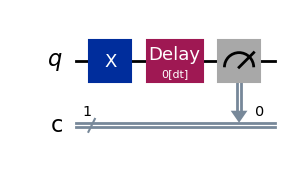

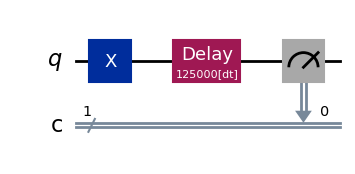

In [41]:
# Build one T1 inversion-recovery circuit for each delay time.
t1_circuits = []

for delay_dt in t1_delay_dt:
    circuit = QuantumCircuit(1, 1)
    circuit.x(0)                         # prepare |1>
    circuit.delay(int(delay_dt), 0, unit='dt')
    circuit.measure(0, 0)
    t1_circuits.append(circuit)

# Inspect the first and last circuit if desired.
display(t1_circuits[0].draw('mpl'))
display(t1_circuits[-1].draw('mpl'))

In [42]:
# Transpile the full circuit batch for the selected backend.
# Using the same pass manager for all circuits keeps the execution target consistent.
pm_t1 = generate_preset_pass_manager(optimization_level=3, backend=backend, initial_layout=[PHYSICAL_QUBIT])
t1_circuits_ibm = pm_t1.run(t1_circuits)

print(f"Prepared {len(t1_circuits_ibm)} transpiled T1 circuits.")

Prepared 25 transpiled T1 circuits.


In [43]:
# Run the T1 circuit list in Open-plan-compatible job mode.
# The list of circuits is submitted as one Sampler job.
sampler = Sampler(mode=backend)
t1_job = sampler.run(t1_circuits_ibm, shots=t1_shots)

print(f"Submitted T1 job: {t1_job.job_id()}")

# This line blocks until the job finishes. Run it when you are ready to collect results.
t1_result = t1_job.result()


Submitted T1 job: d84qm700bvlc73d4sho0


In [44]:
# Convert sampler results into P(1) for each delay time.
t1_counts = [t1_result[i].data.c.get_counts() for i in range(len(t1_circuits_ibm))]
t1_p1 = np.array([p1_from_counts(counts, t1_shots) for counts in t1_counts])
t1_p1_err = np.sqrt(t1_p1 * (1 - t1_p1) / t1_shots)

for delay_us, counts, p1 in zip(actual_t1_delay_times_us, t1_counts, t1_p1):
    print(f"delay = {delay_us:8.3f} us, counts = {counts}, P(1) = {p1:.4f}")

delay =    0.000 us, counts = {'1': 1017, '0': 7}, P(1) = 0.9932
delay =   20.832 us, counts = {'1': 888, '0': 136}, P(1) = 0.8672
delay =   41.668 us, counts = {'1': 782, '0': 242}, P(1) = 0.7637
delay =   62.500 us, counts = {'0': 323, '1': 701}, P(1) = 0.6846
delay =   83.332 us, counts = {'0': 404, '1': 620}, P(1) = 0.6055
delay =  104.168 us, counts = {'1': 556, '0': 468}, P(1) = 0.5430
delay =  125.000 us, counts = {'0': 502, '1': 522}, P(1) = 0.5098
delay =  145.832 us, counts = {'0': 551, '1': 473}, P(1) = 0.4619
delay =  166.668 us, counts = {'0': 567, '1': 457}, P(1) = 0.4463
delay =  187.500 us, counts = {'1': 420, '0': 604}, P(1) = 0.4102
delay =  208.332 us, counts = {'1': 384, '0': 640}, P(1) = 0.3750
delay =  229.168 us, counts = {'0': 702, '1': 322}, P(1) = 0.3145
delay =  250.000 us, counts = {'0': 732, '1': 292}, P(1) = 0.2852
delay =  270.832 us, counts = {'0': 754, '1': 270}, P(1) = 0.2637
delay =  291.668 us, counts = {'0': 762, '1': 262}, P(1) = 0.2559
delay =  31

In [45]:
# Fit P(1) to an exponential decay and extract T1.
initial_amplitude = max(t1_p1[0] - t1_p1[-1], 0.1)
initial_T1 = max(actual_t1_delay_times_s[-1] / 3, backend.dt)
initial_offset = min(max(t1_p1[-1], 0.0), 1.0)

p0 = [initial_amplitude, initial_T1, initial_offset]
bounds = ([0.0, backend.dt, 0.0], [1.0, np.inf, 1.0])

t1_fit_params, t1_fit_cov = curve_fit(
    t1_decay_model,
    actual_t1_delay_times_s,
    t1_p1,
    p0=p0,
    bounds=bounds,
    sigma=np.maximum(t1_p1_err, 1 / t1_shots),
    absolute_sigma=True,
    maxfev=10000,
)

t1_amplitude, t1_time_s, t1_offset = t1_fit_params
t1_time_err_s = np.sqrt(np.diag(t1_fit_cov))[1]

print(f"Estimated T1 = {1e6 * t1_time_s:.2f} +/- {1e6 * t1_time_err_s:.2f} us")
print(f"Fit parameters: A = {t1_amplitude:.4f}, B = {t1_offset:.4f}")

Estimated T1 = 167.20 +/- 4.30 us
Fit parameters: A = 0.9110, B = 0.0801


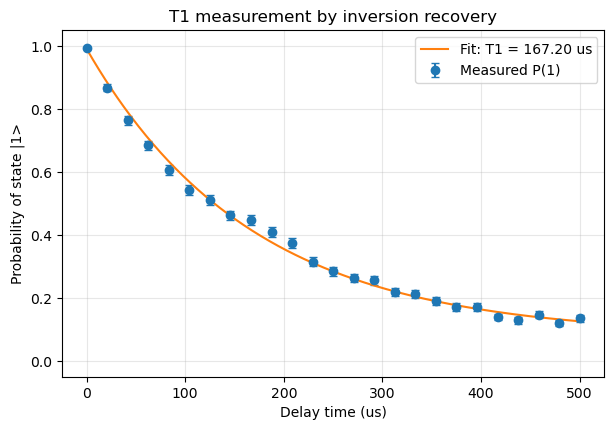

In [46]:
# Plot the measured data and fitted T1 curve.
fit_t_s = np.linspace(actual_t1_delay_times_s[0], actual_t1_delay_times_s[-1], 400)
fit_p1 = t1_decay_model(fit_t_s, *t1_fit_params)

plt.figure(figsize=(7, 4.5))
plt.errorbar(
    actual_t1_delay_times_us,
    t1_p1,
    yerr=t1_p1_err,
    fmt='o',
    capsize=3,
    label='Measured P(1)',
)
plt.plot(1e6 * fit_t_s, fit_p1, label=f'Fit: T1 = {1e6 * t1_time_s:.2f} us')
plt.xlabel('Delay time (us)')
plt.ylabel('Probability of state |1>')
plt.title('T1 measurement by inversion recovery')
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### T1 결과 해석

T1 측정에서는 qubit을 $|1\rangle$ 상태로 준비한 뒤 여러 delay time 동안 기다리고, 마지막에 $|1\rangle$로 측정될 확률 $P(1)$을 구하였다. 그래프에서 delay time이 증가할수록 $P(1)$이 감소하는 형태를 확인할 수 있었고, 이는 excited state인 $|1\rangle$이 시간이 지나면서 ground state인 $|0\rangle$로 relaxation되는 현상을 보여 준다.

측정값을 $P(1)=A e^{-t/T_1}+B$로 fitting한 결과 $T_1 = 167.20 \pm 4.30~\mu s$를 얻었다. 같은 실험에 사용한 physical qubit 149의 backend calibration T1 값은 $251.36~\mu s$였으므로, 실제 측정값은 calibration 값과 같은 order이지만 완전히 같지는 않다. 이는 calibration 시점, queue 이후의 backend 상태, readout error, gate error 등에 따라 실제 측정 결과가 달라질 수 있음을 의미한다.

### Homework B: Ramsey interferometry를 이용한 T2* 측정

이 절에서는 Ramsey interferometry를 이용해 $T_2^*$를 측정한다. qubit을 superposition 상태로 만든 뒤 delay time 동안 phase가 축적되게 하고, 다시 $\pi/2$ pulse를 가해 phase 정보를 population 측정으로 변환한다. 또한 $R_z$ gate로 artificial detuning phase를 넣어 Ramsey fringe가 그래프에서 잘 보이도록 하였다.

측정 결과는

$$
P(1)=A e^{-t/T_2^*}\cos(2\pi f t+\phi)+B
$$

형태의 감쇠 진동 함수로 fitting한다. 여기서 envelope의 감쇠 시간이 $T_2^*$이다.

In [47]:
# Ramsey fitting model for Homework B.
def ramsey_decay_model(t, amplitude, T2star, frequency, phase, offset):
    """Damped Ramsey oscillation: P(1) = A exp(-t/T2*) cos(2 pi f t + phi) + B."""
    return amplitude * np.exp(-t / T2star) * np.cos(2 * np.pi * frequency * t + phase) + offset

In [48]:
# Choose Ramsey delay sweep parameters.
# ramsey_detuning_hz is an artificial phase accumulation rate implemented by RZ gates.
ramsey_shots = 1024
ramsey_num_points = 31
ramsey_max_delay_s = 120e-6      # 120 microseconds
ramsey_detuning_hz = 100e3       # 100 kHz gives a 10 us oscillation period

ramsey_delay_times_s = np.linspace(0, ramsey_max_delay_s, ramsey_num_points)
ramsey_delay_dt = np.array([seconds_to_dt(t, backend) for t in ramsey_delay_times_s], dtype=int)
actual_ramsey_delay_times_s = ramsey_delay_dt * backend.dt
actual_ramsey_delay_times_us = 1e6 * actual_ramsey_delay_times_s
ramsey_phases = 2 * np.pi * ramsey_detuning_hz * actual_ramsey_delay_times_s

print(f"Backend: {backend.name}")
print(f"backend.dt = {backend.dt:.3e} s")
print(f"Delay range: {actual_ramsey_delay_times_us[0]:.3f} us to {actual_ramsey_delay_times_us[-1]:.3f} us")
print(f"Artificial Ramsey detuning: {ramsey_detuning_hz / 1e3:.1f} kHz")
print(f"Number of circuits: {len(ramsey_delay_dt)}")

Backend: ibm_kingston
backend.dt = 4.000e-09 s
Delay range: 0.000 us to 120.000 us
Artificial Ramsey detuning: 100.0 kHz
Number of circuits: 31


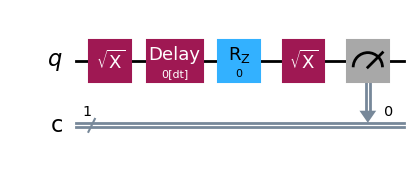

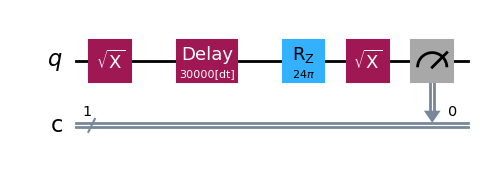

In [49]:
# Build one Ramsey circuit for each delay time.
ramsey_circuits = []

for delay_dt, phase in zip(ramsey_delay_dt, ramsey_phases):
    circuit = QuantumCircuit(1, 1)
    circuit.sx(0)                         # first pi/2 pulse: prepare superposition
    circuit.delay(int(delay_dt), 0, unit='dt')
    circuit.rz(float(phase), 0)            # virtual-Z phase for visible Ramsey fringes
    circuit.sx(0)                         # second pi/2 pulse: convert phase to population
    circuit.measure(0, 0)
    ramsey_circuits.append(circuit)

# Inspect the first and last circuit if desired.
display(ramsey_circuits[0].draw('mpl'))
display(ramsey_circuits[-1].draw('mpl'))

In [50]:
# Transpile the Ramsey circuit batch for the selected backend.
pm_ramsey = generate_preset_pass_manager(optimization_level=3, backend=backend, initial_layout=[PHYSICAL_QUBIT])
ramsey_circuits_ibm = pm_ramsey.run(ramsey_circuits)

print(f"Prepared {len(ramsey_circuits_ibm)} transpiled Ramsey circuits.")

Prepared 31 transpiled Ramsey circuits.


In [51]:
# Run the Ramsey circuit list in Open-plan-compatible job mode.
sampler = Sampler(mode=backend)
ramsey_job = sampler.run(ramsey_circuits_ibm, shots=ramsey_shots)

print(f"Submitted Ramsey job: {ramsey_job.job_id()}")

# This line blocks until the job finishes. Run it when you are ready to collect results.
ramsey_result = ramsey_job.result()

Submitted Ramsey job: d84qmhnoha1c73bo3o60


In [52]:
# Convert sampler results into P(1) for each Ramsey delay time.
ramsey_counts = [ramsey_result[i].data.c.get_counts() for i in range(len(ramsey_circuits_ibm))]
ramsey_p1 = np.array([p1_from_counts(counts, ramsey_shots) for counts in ramsey_counts])
ramsey_p1_err = np.sqrt(ramsey_p1 * (1 - ramsey_p1) / ramsey_shots)

for delay_us, counts, p1 in zip(actual_ramsey_delay_times_us, ramsey_counts, ramsey_p1):
    print(f"delay = {delay_us:8.3f} us, counts = {counts}, P(1) = {p1:.4f}")

delay =    0.000 us, counts = {'1': 1020, '0': 4}, P(1) = 0.9961
delay =    4.000 us, counts = {'0': 801, '1': 223}, P(1) = 0.2178
delay =    8.000 us, counts = {'1': 377, '0': 647}, P(1) = 0.3682
delay =   12.000 us, counts = {'1': 923, '0': 101}, P(1) = 0.9014
delay =   16.000 us, counts = {'0': 868, '1': 156}, P(1) = 0.1523
delay =   20.000 us, counts = {'0': 481, '1': 543}, P(1) = 0.5303
delay =   24.000 us, counts = {'0': 249, '1': 775}, P(1) = 0.7568
delay =   28.000 us, counts = {'1': 213, '0': 811}, P(1) = 0.2080
delay =   32.000 us, counts = {'0': 384, '1': 640}, P(1) = 0.6250
delay =   36.000 us, counts = {'0': 363, '1': 661}, P(1) = 0.6455
delay =   40.000 us, counts = {'1': 283, '0': 741}, P(1) = 0.2764
delay =   44.000 us, counts = {'0': 417, '1': 607}, P(1) = 0.5928
delay =   48.000 us, counts = {'1': 624, '0': 400}, P(1) = 0.6094
delay =   52.000 us, counts = {'0': 695, '1': 329}, P(1) = 0.3213
delay =   56.000 us, counts = {'0': 429, '1': 595}, P(1) = 0.5811
delay =   6

In [53]:
# Fit Ramsey data to a damped cosine and extract T2*.
ramsey_initial_amplitude = 0.5 * (np.max(ramsey_p1) - np.min(ramsey_p1))
if ramsey_initial_amplitude < 0.02:
    ramsey_initial_amplitude = 0.1

ramsey_initial_T2star = max(actual_ramsey_delay_times_s[-1] / 2, backend.dt)
ramsey_initial_offset = min(max(np.mean(ramsey_p1), 0.0), 1.0)
ramsey_initial_phase = 0.0

ramsey_p0 = [
    ramsey_initial_amplitude,
    ramsey_initial_T2star,
    ramsey_detuning_hz,
    ramsey_initial_phase,
    ramsey_initial_offset,
]

ramsey_bounds = (
    [-1.0, backend.dt, 0.0, -2 * np.pi, 0.0],
    [1.0, np.inf, 2.0e6, 2 * np.pi, 1.0],
)

try:
    ramsey_fit_params, ramsey_fit_cov = curve_fit(
        ramsey_decay_model,
        actual_ramsey_delay_times_s,
        ramsey_p1,
        p0=ramsey_p0,
        bounds=ramsey_bounds,
        sigma=np.maximum(ramsey_p1_err, 1 / ramsey_shots),
        absolute_sigma=True,
        maxfev=30000,
    )
    ramsey_fit_success = True

    ramsey_amplitude, t2star_time_s, ramsey_fit_frequency, ramsey_phase, ramsey_offset = ramsey_fit_params
    t2star_time_err_s = np.sqrt(np.diag(ramsey_fit_cov))[1]

    print(f"Estimated T2* = {1e6 * t2star_time_s:.2f} +/- {1e6 * t2star_time_err_s:.2f} us")
    print(f"Fit frequency = {ramsey_fit_frequency / 1e3:.2f} kHz")
    print(f"Fit parameters: A = {ramsey_amplitude:.4f}, phi = {ramsey_phase:.4f}, B = {ramsey_offset:.4f}")
except RuntimeError as fit_error:
    ramsey_fit_success = False
    print("Ramsey fit did not converge. Try changing ramsey_detuning_hz, ramsey_max_delay_s, or ramsey_num_points.")
    print(fit_error)

Estimated T2* = 80.16 +/- 2.11 us
Fit frequency = 85.24 kHz
Fit parameters: A = 0.4959, phi = 0.2285, B = 0.5100


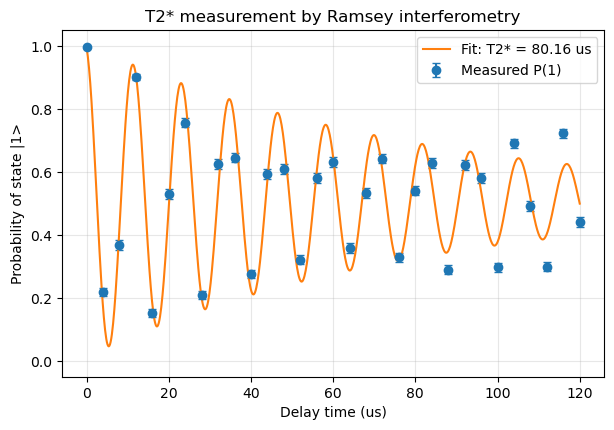

In [54]:
# Plot the measured Ramsey fringes and the fitted damped oscillation.
plt.figure(figsize=(7, 4.5))
plt.errorbar(
    actual_ramsey_delay_times_us,
    ramsey_p1,
    yerr=ramsey_p1_err,
    fmt='o',
    capsize=3,
    label='Measured P(1)',
)

if ramsey_fit_success:
    ramsey_fit_t_s = np.linspace(actual_ramsey_delay_times_s[0], actual_ramsey_delay_times_s[-1], 800)
    ramsey_fit_p1 = ramsey_decay_model(ramsey_fit_t_s, *ramsey_fit_params)
    plt.plot(
        1e6 * ramsey_fit_t_s,
        ramsey_fit_p1,
        label=f'Fit: T2* = {1e6 * t2star_time_s:.2f} us',
    )

plt.xlabel('Delay time (us)')
plt.ylabel('Probability of state |1>')
plt.title('T2* measurement by Ramsey interferometry')
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Ramsey T2* 결과 해석

Ramsey interferometry에서는 qubit을 superposition 상태로 만든 뒤 delay time 동안 phase가 축적되도록 하고, 다시 $\pi/2$ pulse를 가해 phase 정보를 population 측정으로 변환하였다. 그래프에서는 $P(1)$이 단순히 감소하는 것이 아니라 진동하면서 감쇠하는 Ramsey fringe가 나타난다. 이 진동은 artificial detuning phase에 의해 만들어진 것이고, 그 envelope의 감소가 dephasing을 나타낸다.

측정값을 $P(1)=A e^{-t/T_2^*}\cos(2\pi f t+\phi)+B$로 fitting한 결과 $T_2^* = 80.16 \pm 2.11~\mu s$를 얻었다. 이 값은 $T_1 = 167.20~\mu s$보다 짧다. 이는 Ramsey 측정에서는 energy relaxation뿐 아니라 qubit frequency fluctuation과 같은 dephasing 효과가 함께 포함되기 때문이다.

### Homework C: Spin-echo를 이용한 T2,echo 측정

이 절에서는 Hahn spin-echo sequence를 이용해 $T_{2,\mathrm{echo}}$를 측정한다. Ramsey sequence의 중간에 $X$ pulse를 넣으면 delay 앞뒤에서 누적된 느린 phase error가 서로 상쇄될 수 있다. 따라서 spin-echo로 얻은 coherence time은 보통 Ramsey에서 얻은 $T_2^*$보다 길게 나타난다.

사용한 회로는 다음과 같다.

$$
H \rightarrow delay(t/2) \rightarrow X \rightarrow delay(t/2) \rightarrow H \rightarrow X \rightarrow measurement
$$

마지막 $X$ gate는 readout convention을 뒤집기 위한 것으로, echo가 잘 보존되었을 때 $P(1)$이 1에 가깝게 시작하도록 한다.

In [64]:
# Spin-echo fitting model for Homework C.
def echo_decay_model(t, amplitude, T2echo, offset):
    """Echo decay model: P(1) = A exp(-t/T2echo) + B."""
    return amplitude * np.exp(-t / T2echo) + offset

In [65]:
# Choose spin-echo delay sweep parameters.
# T2_echo is often longer than T2*, so the default max delay is larger than the Ramsey sweep.
echo_shots = 1024
echo_num_points = 25
echo_max_delay_s = 400e-6  # 400 microseconds total free-evolution time

echo_delay_times_s = np.linspace(0, echo_max_delay_s, echo_num_points)
echo_delay_dt = np.array([seconds_to_dt(t, backend) for t in echo_delay_times_s], dtype=int)
actual_echo_delay_times_s = echo_delay_dt * backend.dt
actual_echo_delay_times_us = 1e6 * actual_echo_delay_times_s

print(f"Backend: {backend.name}")
print(f"backend.dt = {backend.dt:.3e} s")
print(f"Total echo delay range: {actual_echo_delay_times_us[0]:.3f} us to {actual_echo_delay_times_us[-1]:.3f} us")
print(f"Number of circuits: {len(echo_delay_dt)}")

Backend: ibm_kingston
backend.dt = 4.000e-09 s
Total echo delay range: 0.000 us to 400.000 us
Number of circuits: 25


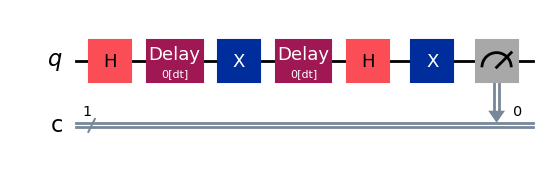

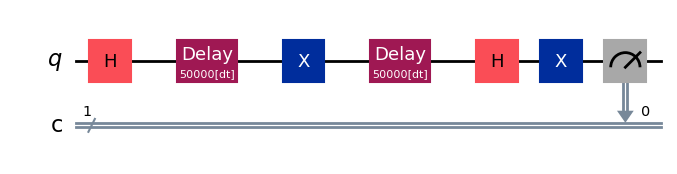

In [66]:
# Build one Hahn echo circuit for each total delay time.
echo_circuits = []

for total_delay_dt in echo_delay_dt:
    first_half_dt = int(total_delay_dt // 2)
    second_half_dt = int(total_delay_dt - first_half_dt)

    circuit = QuantumCircuit(1, 1)
    circuit.h(0)                              # prepare |+>
    circuit.delay(first_half_dt, 0, unit='dt')
    circuit.x(0)                              # echo pi pulse
    circuit.delay(second_half_dt, 0, unit='dt')
    circuit.h(0)                              # analyze recovered phase
    circuit.x(0)                              # flip readout so preserved echo gives P(1) near 1
    circuit.measure(0, 0)
    echo_circuits.append(circuit)

# Inspect the first and last circuit if desired.
display(echo_circuits[0].draw('mpl'))
display(echo_circuits[-1].draw('mpl'))

In [67]:
# Transpile the spin-echo circuit batch for the selected backend.
pm_echo = generate_preset_pass_manager(optimization_level=3, backend=backend, initial_layout=[PHYSICAL_QUBIT])
echo_circuits_ibm = pm_echo.run(echo_circuits)

print(f"Prepared {len(echo_circuits_ibm)} transpiled spin-echo circuits.")

Prepared 25 transpiled spin-echo circuits.


In [68]:
# Run the spin-echo circuit list in Open-plan-compatible job mode.
sampler = Sampler(mode=backend)
echo_job = sampler.run(echo_circuits_ibm, shots=echo_shots)

print(f"Submitted spin-echo job: {echo_job.job_id()}")

# This line blocks until the job finishes. Run it when you are ready to collect results.
echo_result = echo_job.result()

Submitted spin-echo job: d84quknoha1c73bo40dg


In [69]:
# Convert sampler results into P(1) for each total echo delay time.
echo_counts = [echo_result[i].data.c.get_counts() for i in range(len(echo_circuits_ibm))]
echo_p1 = np.array([p1_from_counts(counts, echo_shots) for counts in echo_counts])
echo_p1_err = np.sqrt(echo_p1 * (1 - echo_p1) / echo_shots)

for delay_us, counts, p1 in zip(actual_echo_delay_times_us, echo_counts, echo_p1):
    print(f"delay = {delay_us:8.3f} us, counts = {counts}, P(1) = {p1:.4f}")

delay =    0.000 us, counts = {'1': 1016, '0': 8}, P(1) = 0.9922
delay =   16.668 us, counts = {'0': 69, '1': 955}, P(1) = 0.9326
delay =   33.332 us, counts = {'1': 895, '0': 129}, P(1) = 0.8740
delay =   50.000 us, counts = {'1': 884, '0': 140}, P(1) = 0.8633
delay =   66.668 us, counts = {'1': 843, '0': 181}, P(1) = 0.8232
delay =   83.332 us, counts = {'1': 822, '0': 202}, P(1) = 0.8027
delay =  100.000 us, counts = {'1': 794, '0': 230}, P(1) = 0.7754
delay =  116.668 us, counts = {'1': 784, '0': 240}, P(1) = 0.7656
delay =  133.332 us, counts = {'1': 759, '0': 265}, P(1) = 0.7412
delay =  150.000 us, counts = {'0': 284, '1': 740}, P(1) = 0.7227
delay =  166.668 us, counts = {'1': 715, '0': 309}, P(1) = 0.6982
delay =  183.332 us, counts = {'1': 708, '0': 316}, P(1) = 0.6914
delay =  200.000 us, counts = {'0': 311, '1': 713}, P(1) = 0.6963
delay =  216.668 us, counts = {'0': 327, '1': 697}, P(1) = 0.6807
delay =  233.332 us, counts = {'1': 663, '0': 361}, P(1) = 0.6475
delay =  250

In [70]:
# Fit spin-echo data to an exponential decay and extract T2_echo.
echo_initial_amplitude = max(echo_p1[0] - echo_p1[-1], 0.05)
echo_initial_T2 = max(actual_echo_delay_times_s[-1] / 2, backend.dt)
echo_initial_offset = min(max(echo_p1[-1], 0.0), 1.0)

echo_p0 = [echo_initial_amplitude, echo_initial_T2, echo_initial_offset]
echo_bounds = ([0.0, backend.dt, 0.0], [1.0, np.inf, 1.0])

echo_fit_params, echo_fit_cov = curve_fit(
    echo_decay_model,
    actual_echo_delay_times_s,
    echo_p1,
    p0=echo_p0,
    bounds=echo_bounds,
    sigma=np.maximum(echo_p1_err, 1 / echo_shots),
    absolute_sigma=True,
    maxfev=10000,
)

echo_amplitude, t2echo_time_s, echo_offset = echo_fit_params
t2echo_time_err_s = np.sqrt(np.diag(echo_fit_cov))[1]

print(f"Estimated T2_echo = {1e6 * t2echo_time_s:.2f} +/- {1e6 * t2echo_time_err_s:.2f} us")
print(f"Fit parameters: A = {echo_amplitude:.4f}, B = {echo_offset:.4f}")

Estimated T2_echo = 150.61 +/- 9.04 us
Fit parameters: A = 0.4319, B = 0.5575


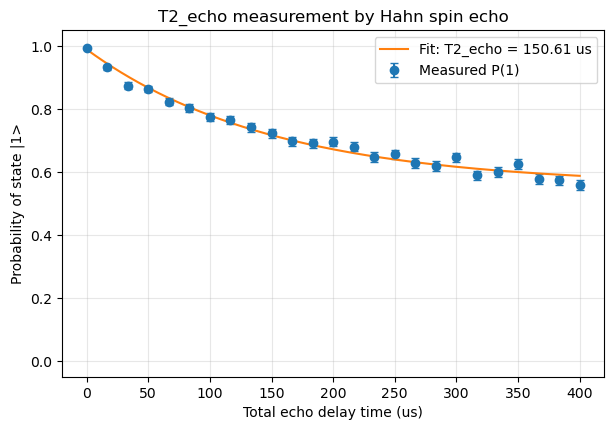

In [71]:
# Plot the measured echo decay and fitted curve.
echo_fit_t_s = np.linspace(actual_echo_delay_times_s[0], actual_echo_delay_times_s[-1], 400)
echo_fit_p1 = echo_decay_model(echo_fit_t_s, *echo_fit_params)

plt.figure(figsize=(7, 4.5))
plt.errorbar(
    actual_echo_delay_times_us,
    echo_p1,
    yerr=echo_p1_err,
    fmt='o',
    capsize=3,
    label='Measured P(1)',
)
plt.plot(1e6 * echo_fit_t_s, echo_fit_p1, label=f'Fit: T2_echo = {1e6 * t2echo_time_s:.2f} us')
plt.xlabel('Total echo delay time (us)')
plt.ylabel('Probability of state |1>')
plt.title('T2_echo measurement by Hahn spin echo')
plt.ylim(-0.05, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Spin-echo T2,echo 결과 해석

Spin-echo 측정에서는 Ramsey sequence 중간에 $X$ pulse를 넣어 앞뒤 delay 구간에서 누적된 느린 phase error가 서로 상쇄되도록 하였다. 그래프에서는 echo pulse를 넣은 뒤에도 delay time이 길어질수록 $P(1)$이 감쇠하는 모습을 확인할 수 있다. 즉 spin-echo가 dephasing을 완전히 제거하는 것은 아니지만, Ramsey 실험보다 coherence를 더 오래 유지하게 해 준다.

측정값을 $P(1)=A e^{-t/T_{2,\mathrm{echo}}}+B$로 fitting한 결과 $T_{2,\mathrm{echo}} = 150.61 \pm 9.04~\mu s$를 얻었다. 이 값은 $T_2^* = 80.16~\mu s$보다 약 1.88배 길다. 따라서 이번 결과는 spin-echo pulse가 low-frequency dephasing noise를 상당 부분 refocusing했다는 것을 보여 준다.

In [72]:
# Compare T2_echo with Ramsey T2* and the relaxation bound 2T1.
print(f"T2_echo = {1e6 * t2echo_time_s:.2f} +/- {1e6 * t2echo_time_err_s:.2f} us")

if 't2star_time_s' in globals():
    print(f"T2*      = {1e6 * t2star_time_s:.2f} us")
    print(f"T2_echo / T2* = {t2echo_time_s / t2star_time_s:.3f}")
    if t2echo_time_s > t2star_time_s:
        print("Result: T2_echo is longer than T2*, as expected when echo refocuses slow dephasing noise.")
    else:
        print("Result: T2_echo is not longer than T2*. This can happen with noisy data, pulse errors, or an insufficient delay range.")
else:
    print("T2* value is not available. Run the Ramsey fitting cells before this comparison.")

if 't1_time_s' in globals():
    two_t1_s = 2 * t1_time_s
    print(f"2T1      = {1e6 * two_t1_s:.2f} us")
    print(f"T2_echo / (2T1) = {t2echo_time_s / two_t1_s:.3f}")
    if np.isclose(t2echo_time_s, two_t1_s, rtol=0.2):
        print("Result: T2_echo is approximately consistent with the 2T1 limit within 20%.")
    elif t2echo_time_s < two_t1_s:
        print("Result: T2_echo is shorter than 2T1, indicating additional dephasing beyond energy relaxation.")
    else:
        print("Result: T2_echo is larger than 2T1. Check fit uncertainty, SPAM errors, and delay range because 2T1 is the usual relaxation-limited upper bound.")
else:
    print("T1 value is not available. Run the T1 fitting cells before this comparison.")

T2_echo = 150.61 +/- 9.04 us
T2*      = 80.16 us
T2_echo / T2* = 1.879
Result: T2_echo is longer than T2*, as expected when echo refocuses slow dephasing noise.
2T1      = 334.41 us
T2_echo / (2T1) = 0.450
Result: T2_echo is shorter than 2T1, indicating additional dephasing beyond energy relaxation.


### 최종 비교 및 해석

이번 측정은 같은 backend `ibm_kingston`의 같은 physical qubit 149에 대해 $T_1$, $T_2^*$, $T_{2,\mathrm{echo}}$를 비교했다는 점에서 의미가 있다. 최종 결과는 $T_1 = 167.20 \pm 4.30~\mu s$, $T_2^* = 80.16 \pm 2.11~\mu s$, $T_{2,\mathrm{echo}} = 150.61 \pm 9.04~\mu s$이다.

$T_{2,\mathrm{echo}}/T_2^* = 1.879$이므로 spin-echo coherence time은 Ramsey에서 얻은 $T_2^*$보다 약 1.88배 길게 나타났다. 이는 echo pulse가 느리게 변하는 dephasing noise를 refocusing한 결과로 해석할 수 있다. 그러나 $2T_1 = 334.41~\mu s$이고 $T_{2,\mathrm{echo}}/(2T_1)=0.450$이므로, $T_{2,\mathrm{echo}}$는 relaxation만으로 정해지는 이상적인 상한 $2T_1$에는 도달하지 않는다. 따라서 이번 backend에서는 energy relaxation 외에도 추가적인 dephasing, pulse error, 또는 시간에 따라 변하는 noise가 coherence를 제한하고 있다고 볼 수 있다.